# FitCoach-RL: Multi-Actor Orchestrator Training (Colab)

Trains an LLM (`Qwen2.5-1.5B-Instruct`) as a **fitness orchestrator** using **GRPO** against the FitCoach multi-actor RL environment.

### Why this version is different from the template
- **No HTTP server** — the reward function calls `FitcoachEnvironment` directly in Python, so port conflicts and 500 errors disappear.
- **Cells reordered** — the model/tokenizer is loaded **before** the dataset is built (the template referenced `tokenizer` before it existed).
- **Patches a `KeyError` bug** in `utils/actors.py` (`progress_actor` crashed when `signals[0]` was `overshooting` / `overtraining`).
- **`training_log` is initialized before the reward test**, not after.

### Runtime
Runtime → Change runtime type → **T4 GPU** (or better).

## Step 1 — Install dependencies

In [1]:
%%capture
!pip install unsloth
!pip install --no-deps "trl>=0.12.0" peft accelerate bitsandbytes
!pip install datasets "openenv-core>=0.2.2" fastapi uvicorn requests
print('All dependencies installed!')

## Step 2 — Clone the FitCoach environment from your HF Space
We pull your code as a plain repo (no HTTP server needed — we'll import it directly).

In [2]:
import os, sys

REPO_DIR = '/content/FitCoach'
HF_SPACE = 'https://huggingface.co/spaces/coffeine16/FitCoach'

if not os.path.exists(REPO_DIR):
    !git clone $HF_SPACE $REPO_DIR

sys.path.insert(0, REPO_DIR)

for f in [
    'server/FitCoach_environment.py', 'utils/actors.py', 'utils/curriculum.py',
    'utils/nutrition.py', 'utils/plateau.py', 'utils/overload.py', 'models.py',
]:
    path = os.path.join(REPO_DIR, f)
    assert os.path.exists(path), f'Missing: {path}'
    print('  OK', f)

print('\nFitCoach environment ready.')

Cloning into '/content/FitCoach'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 65 (delta 18), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (65/65), 244.96 KiB | 2.63 MiB/s, done.
Resolving deltas: 100% (18/18), done.
  OK server/FitCoach_environment.py
  OK utils/actors.py
  OK utils/curriculum.py
  OK utils/nutrition.py
  OK utils/plateau.py
  OK utils/overload.py
  OK models.py

FitCoach environment ready.


## Step 3 — Patch the `progress_actor` bug
`utils/actors.py` does `signals[0]['required_actions']`, but `overshooting` / `low_adherence-without-pct` / `overtraining` signals don't always carry that key. We replace that line with a safe `.get()` so dataset building doesn't crash.

In [3]:
actors_path = os.path.join(REPO_DIR, 'utils', 'actors.py')
with open(actors_path, 'r', encoding='utf-8') as fh:
    src = fh.read()

old = "+ (f\"Action required: {signals[0]['required_actions']}\" if signals else \"\")"
new = "+ (f\"Action required: {signals[0].get('required_actions', [])}\" if signals else \"\")"

if old in src:
    src = src.replace(old, new)
    with open(actors_path, 'w', encoding='utf-8') as fh:
        fh.write(src)
    print('Patched progress_actor — KeyError fixed.')
else:
    print('Patch line not found — already patched or upstream changed.')

for mod in [m for m in list(sys.modules) if m.startswith('utils') or m.startswith('server')]:
    sys.modules.pop(mod, None)

Patched progress_actor — KeyError fixed.


## Step 4 — Load the model with Unsloth
We must do this **before** building the dataset, because the dataset uses the tokenizer's chat template.

In [4]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME      = 'unsloth/Qwen2.5-1.5B-Instruct'
MAX_SEQ_LENGTH  = 3072

print('Loading', MODEL_NAME)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = None,
    load_in_4bit    = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r                          = 16,
    target_modules             = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                                  'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha                 = 32,
    lora_dropout               = 0,
    bias                       = 'none',
    use_gradient_checkpointing = 'unsloth',
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

print('Model + LoRA ready (Unsloth 4-bit).')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2.5-1.5B-Instruct
GPU: Tesla T4
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model + LoRA ready (Unsloth 4-bit).


## Step 5 — Reward function (direct Python, no HTTP)
Each completion runs a full episode against `FitcoachEnvironment`:
1. `reset()` → random client (curriculum mode)
2. consult fitness / nutrition / progress actors
3. submit the model's plan
4. return the environment reward (8 dims, soft-min aggregated, 0–1)

Note: `training_log` is initialized **before** the test below.

In [5]:
import json
import re

def extract_json(text):
    if isinstance(text, dict):
        return text

    try:
        return json.loads(text)
    except:
        pass

    # fallback: non-greedy match
    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if not match:
        return None

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except:
        return None

In [6]:
import json, threading
from server.FitCoach_environment import FitcoachEnvironment
from models import FitcoachAction
from utils.curriculum import generate_client
from utils.actors import fitness_actor, nutrition_actor, progress_actor

training_log = {'step_rewards': [], 'step_difficulties': [], 'step_breakdowns': []}

_local = threading.local()
def get_env():
    if not hasattr(_local, 'env'):
        _local.env = FitcoachEnvironment(task_id='curriculum')
    return _local.env

def run_full_episode(plan_json, **kwargs):
    try:
        # Handle any input type
        if isinstance(plan_json, dict):
            plan_json = plan_json.get('content', str(plan_json))
        elif isinstance(plan_json, list):
            plan_json = plan_json[-1].get('content', '') if plan_json else ''
        elif not isinstance(plan_json, str):
            plan_json = str(plan_json)

        env = get_env()
        env.reset()
        for actor in ['fitness_advisor', 'nutrition_advisor', 'progress_analyst']:
            env.step(FitcoachAction(
                action_type='consult_actor', actor_target=actor,
                workout_plan='{}', nutrition_plan='{}'))

        text = plan_json.strip()
        if '```' in text:
            lines = [l for l in text.split('\n') if not l.strip().startswith('```')]
            text = '\n'.join(lines)

        start = text.find('{')
        if start == -1:
            return 0.0, {}, 'easy'

        end = len(text)
        parsed = None
        for _ in range(5):
            try:
                parsed = extract_json(text)
                print(parsed)
                break
            except json.JSONDecodeError:
                end = text.rfind('}', start, end - 1)
                if end == -1:
                    break
                end += 1

        if parsed is None:
            return 0.0, {}, 'easy'

        result = env.step(FitcoachAction(
            action_type='submit_plan',
            workout_plan=json.dumps(parsed.get('workout_plan', {})),
            nutrition_plan=json.dumps(parsed.get('nutrition_plan', {})),
            reasoning='GRPO',
        ))

        reward = float(result.reward or 0.0)
        breakdown = dict(result.score_breakdown or {})
        difficulty = 'easy'
        fb = result.feedback or ''
        if 'MEDIUM' in fb: difficulty = 'medium'
        elif 'HARD' in fb: difficulty = 'hard'
        return reward, breakdown, difficulty

    except Exception as e:
        print(f'Episode error: {e}')
        return 0.0, {}, 'easy'

print('run_full_episode replaced — dict guard active')


def fitcoach_reward_fn(completions, **kwargs):
    rewards = []
    for completion in completions:
        if isinstance(completion, list):
            text = completion[-1].get('content', '') if completion else ''
        elif isinstance(completion, dict):
            text = completion.get('content', str(completion))
        else:
            text = str(completion)

        reward, breakdown, difficulty = run_full_episode(text)
        training_log['step_rewards'].append(reward)
        training_log['step_difficulties'].append(difficulty)
        training_log['step_breakdowns'].append(breakdown)
        rewards.append(reward)
    return rewards

bad_plan = json.dumps({
    'workout_plan': {'days': [], 'weekly_volume_sets': 0},
    'nutrition_plan': {'daily_targets': {'calories': 1000, 'protein_g': 30}},
})
good_plan = json.dumps({
    'workout_plan': {
        'days': [
            {'name': 'Day 1', 'focus': 'upper', 'exercises': [
                {'name': 'Dumbbell Bench Press', 'sets': 3, 'reps': '8-12', 'rest_seconds': 90, 'weight_kg': 15},
                {'name': 'Dumbbell Row',         'sets': 3, 'reps': '8-12', 'rest_seconds': 90, 'weight_kg': 15},
                {'name': 'Dumbbell Shoulder Press','sets': 2,'reps': '8-12','rest_seconds': 60, 'weight_kg': 10},
            ]},
            {'name': 'Day 2', 'focus': 'lower', 'exercises': [
                {'name': 'Dumbbell Squat',           'sets': 3, 'reps': '8-12',  'rest_seconds': 90, 'weight_kg': 20},
                {'name': 'Dumbbell Romanian Deadlift','sets': 3,'reps': '10-12','rest_seconds': 90, 'weight_kg': 18},
            ]},
        ],
        'weekly_volume_sets': 14,
    },
    'nutrition_plan': {
        'daily_targets': {'calories': 2650, 'protein_g': 144, 'carbs_g': 350, 'fats_g': 74},
        'meals': [
            {'meal_name': 'Breakfast', 'foods': ['100g oats', '200ml milk', '1 banana'], 'calories': 500, 'protein_g': 20},
            {'meal_name': 'Lunch',     'foods': ['150g paneer', '2 roti', '100g rajma'], 'calories': 700, 'protein_g': 45},
        ],
    },
})

print('Testing reward function...')
bad_r  = fitcoach_reward_fn([bad_plan])
good_r = fitcoach_reward_fn([good_plan])
print(f'Bad plan:  {bad_r[0]:.2f}')
print(f'Good plan: {good_r[0]:.2f}')
print(f'Gap: {good_r[0] - bad_r[0]:+.2f} (this is what GRPO optimizes)')

training_log = {'step_rewards': [], 'step_difficulties': [], 'step_breakdowns': []}

run_full_episode replaced — dict guard active
Testing reward function...
{'workout_plan': {'days': [], 'weekly_volume_sets': 0}, 'nutrition_plan': {'daily_targets': {'calories': 1000, 'protein_g': 30}}}
{'workout_plan': {'days': [{'name': 'Day 1', 'focus': 'upper', 'exercises': [{'name': 'Dumbbell Bench Press', 'sets': 3, 'reps': '8-12', 'rest_seconds': 90, 'weight_kg': 15}, {'name': 'Dumbbell Row', 'sets': 3, 'reps': '8-12', 'rest_seconds': 90, 'weight_kg': 15}, {'name': 'Dumbbell Shoulder Press', 'sets': 2, 'reps': '8-12', 'rest_seconds': 60, 'weight_kg': 10}]}, {'name': 'Day 2', 'focus': 'lower', 'exercises': [{'name': 'Dumbbell Squat', 'sets': 3, 'reps': '8-12', 'rest_seconds': 90, 'weight_kg': 20}, {'name': 'Dumbbell Romanian Deadlift', 'sets': 3, 'reps': '10-12', 'rest_seconds': 90, 'weight_kg': 18}]}], 'weekly_volume_sets': 14}, 'nutrition_plan': {'daily_targets': {'calories': 2650, 'protein_g': 144, 'carbs_g': 350, 'fats_g': 74}, 'meals': [{'meal_name': 'Breakfast', 'foods': ['

## Step 6 — Build the training dataset (with actor constraints in the prompt)

In [7]:
from datasets import Dataset

SYSTEM_MSG = (
    'You are a fitness plan generator. Given a client profile and specialist '
    'advisor constraints, generate a workout and nutrition plan as JSON.\n\n'
    'RULES:\n'
    '- ONLY use exercises possible with the listed equipment\n'
    '- NEVER use exercises marked as BANNED\n'
    '- Calories must be within +/-15% of the advisor\'s target\n'
    '- Protein must meet the advisor\'s minimum\n'
    '- weekly_volume_sets must be within the advisor\'s range\n'
    '- NEVER include foods marked as BANNED\n'
    '- Use Indian foods (IFCT 2017) when client has Indian dietary restrictions\n\n'
    'Respond with ONLY a JSON object, no other text:\n'
    '{\n'
    '  "workout_plan": {\n'
    '    "days": [{"name": str, "focus": str, "exercises": [\n'
    '      {"name": str, "sets": int, "reps": str, "rest_seconds": int, "weight_kg": float}\n'
    '    ]}],\n'
    '    "weekly_volume_sets": int, "notes": str\n'
    '  },\n'
    '  "nutrition_plan": {\n'
    '    "daily_targets": {"calories": float, "protein_g": float, "carbs_g": float, "fats_g": float},\n'
    '    "meals": [{"meal_name": str, "foods": [str], "calories": float, "protein_g": float}]\n'
    '  }\n'
    '}'
)

def extract_constraints_text(actor_data, client):
    lines = []
    fa = actor_data.get('fitness_advisor', {})
    fa_c = fa.get('constraints', {})
    if fa_c:
        lines.append('FITNESS ADVISOR:')
        lines.append(f"  Volume: {fa_c.get('weekly_sets_min', '?')}-{fa_c.get('weekly_sets_max', '?')} sets/week")
        lines.append(f"  Equipment: {fa_c.get('must_use_only_equipment', [])}")
        banned = fa_c.get('must_avoid_exercises', [])
        if banned:
            lines.append(f'  BANNED exercises (injury): {banned}')
        for sig in fa.get('recommendations', {}).get('overload_signals', [])[:3]:
            lines.append(f"  Overload: {sig.get('message', '')}")

    na = actor_data.get('nutrition_advisor', {})
    na_c = na.get('constraints', {})
    if na_c:
        lines.append('NUTRITION ADVISOR:')
        lines.append(f"  Calories target: {na_c.get('calories_target', '?')} kcal (+-15%)")
        lines.append(f"  Protein minimum: {na_c.get('protein_minimum_g', '?')}g")
        banned_foods = na_c.get('banned_foods', [])
        if banned_foods:
            lines.append(f'  BANNED foods: {banned_foods[:6]}')
        rec_foods = na.get('recommendations', {}).get('recommended_foods', [])
        if rec_foods:
            lines.append(f'  Recommended high-protein foods: {rec_foods[:4]}')

    pa = actor_data.get('progress_analyst', {})
    pa_r = pa.get('recommendations', {})
    if pa_r:
        lines.append('PROGRESS ANALYST:')
        lines.append(f"  Plateau status: {pa_r.get('plateau_status', 'unknown')}")
        for sig in pa_r.get('signals', [])[:2]:
            lines.append(f"  Signal: {sig.get('message', '')}")
    return '\n'.join(lines)

def build_training_prompt(client, actor_constraints):
      user_msg = f"""
      Client profile:
      {json.dumps(client, indent=2)}

      Specialist advisor constraints:
      {ct}

      HARD REQUIREMENTS (MUST BE SATISFIED):
      - Calories must be within ±5% of target
      - Protein must be ≥ minimum
      - Weekly volume must be within range
      - Only allowed equipment
      - No banned exercises or foods

      STEP-BY-STEP PROCESS:
      1. Compute exact calorie + protein targets
      2. Decide total weekly sets within range
      3. Distribute sets across days
      4. Construct meals to match macros
      5. VERIFY all constraints are satisfied

      CHECKLIST (must pass ALL):
      [ ] Calories within range
      [ ] Protein meets minimum
      [ ] Volume within limits
      [ ] No banned items
      [ ] Equipment valid

      If ANY constraint is violated, FIX it before output.

      Return ONLY valid JSON.
      """
      return [
        {'role': 'system', 'content': SYSTEM_MSG},
        {'role': 'user',   'content': user_msg},
    ]

def get_actor_constraints_for_client(client_data):
    client        = client_data['client']
    progress      = client_data.get('progress_data', {})
    complications = client_data.get('complications', [])
    fa = fitness_actor(client, progress)
    na = nutrition_actor(client, progress, complications)
    pa = progress_actor(client, progress, complications)
    return extract_constraints_text({
        'fitness_advisor': fa, 'nutrition_advisor': na, 'progress_analyst': pa,
    }, client)

TRAINING_STEPS  = 80
NUM_GENERATIONS = 4
DATASET_SIZE    = TRAINING_STEPS * 2

prompts = []
for i in range(DATASET_SIZE):
    diff        = ['easy', 'medium', 'hard'][i % 3]
    client_data = generate_client(diff, seed=i + 100)
    actor_text  = get_actor_constraints_for_client(client_data)
    prompt_msgs = build_training_prompt(client_data['client'], actor_text)
    prompt_text = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
    prompts.append({'prompt': prompt_text})

dataset = Dataset.from_list(prompts)
print(f'Dataset: {len(dataset)} prompts')
print(f'Difficulty mix: easy/medium/hard = {DATASET_SIZE//3}/{DATASET_SIZE//3}/{DATASET_SIZE - 2*(DATASET_SIZE//3)}')
print(f'Training steps: {TRAINING_STEPS} | Completions per step: {NUM_GENERATIONS}')
print('\n--- Sample prompt (truncated) ---')
print(prompts[0]['prompt'][:800])
print('...')

Dataset: 160 prompts
Difficulty mix: easy/medium/hard = 53/53/54
Training steps: 80 | Completions per step: 4

--- Sample prompt (truncated) ---
<|im_start|>system
You are a fitness plan generator. Given a client profile and specialist advisor constraints, generate a workout and nutrition plan as JSON.

RULES:
- ONLY use exercises possible with the listed equipment
- NEVER use exercises marked as BANNED
- Calories must be within +/-15% of the advisor's target
- Protein must meet the advisor's minimum
- weekly_volume_sets must be within the advisor's range
- NEVER include foods marked as BANNED
- Use Indian foods (IFCT 2017) when client has Indian dietary restrictions

Respond with ONLY a JSON object, no other text:
{
  "workout_plan": {
    "days": [{"name": str, "focus": str, "exercises": [
      {"name": str, "sets": int, "reps": str, "rest_seconds": int, "weight_kg": float}
    ]}],
    "weekly_volume_sets": int, "notes": str
  
...


## Step 7 — Baseline (before training)

In [8]:
import numpy as np

def evaluate_model(model, tokenizer, n_samples=9):
    FastLanguageModel.for_inference(model)
    rewards = []
    for i in range(n_samples):
        diff        = ['easy', 'medium', 'hard'][i % 3]
        client_data = generate_client(diff, seed=1000 + i)
        actor_text  = get_actor_constraints_for_client(client_data)
        prompt_msgs = build_training_prompt(client_data['client'], actor_text)
        prompt_text = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)

        inputs = tokenizer(prompt_text, return_tensors='pt').to(model.device)
        with torch.no_grad():
          out = model.generate(
              **inputs,
              max_new_tokens = 1500,   # reduce (you don't need 2500)
              do_sample      = False,  # 🔥 deterministic
              temperature    = 0.0,
              pad_token_id   = tokenizer.eos_token_id,
          )

        completion = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

        reward, breakdown, _ = run_full_episode(completion)
        rewards.append(reward)
        failing = {k: round(v, 2) for k, v in breakdown.items() if v < 0.7}
        print(f'  Sample {i+1}: reward={reward:.2f} diff={diff} failing={failing}')

    avg = float(np.mean(rewards))
    print(f'  Average: {avg:.3f} +/- {float(np.std(rewards)):.3f}')
    return avg, rewards

print('=== BASELINE (before training) ===')
baseline_avg, baseline_rewards = evaluate_model(model, tokenizer, n_samples=5)
print(f'\nBaseline average: {baseline_avg:.3f}')

=== BASELINE (before training) ===


Both `max_new_tokens` (=1500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'compound lifts for hypertrophy', 'exercises': [{'name': 'Barbell Squat', 'sets': 3, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 80}, {'name': 'Dumbbell Bench Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 45}, {'name': 'Incline Dumbbell Tricep Pushdowns', 'sets': 3, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Pull-ups', 'sets': 1, 'reps': 0, 'rest_seconds': 0, 'weight_kg': 0}]}, {'name': 'Wednesday', 'focus': 'compound lifts for strength', 'exercises': [{'name': 'Deadlift', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 80}, {'name': 'Barbell Row', 'sets': 3, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 45}, {'name': 'Overhead Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 45}, {'name': 'Bench Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 45}]}, {'name': 'Friday', 'focus': 'split routine focusing on isolation exercises', 'exercises': [{'name': 'Lying Barbell Sh

Both `max_new_tokens` (=1500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'strength training', 'exercises': [{'name': 'Dumbbell Romanian Deadlift', 'sets': 3, 'reps': '10-12', 'rest_seconds': 15, 'weight_kg': 20.0}, {'name': 'Pull-ups', 'sets': 2, 'reps': '7-12', 'rest_seconds': 0, 'weight_kg': 0.0}]}, {'name': 'Wednesday', 'focus': 'cardio', 'exercises': [{'name': 'Jumping Jacks', 'sets': 3, 'reps': '15-20', 'rest_seconds': 0, 'weight_kg': 0.0}, {'name': 'Burpees', 'sets': 2, 'reps': '15-20', 'rest_seconds': 0, 'weight_kg': 0.0}]}, {'name': 'Friday', 'focus': 'strength training', 'exercises': [{'name': 'Bench Press', 'sets': 3, 'reps': '8-12', 'rest_seconds': 15, 'weight_kg': 10.0}, {'name': 'Overhead Press', 'sets': 2, 'reps': '8-12', 'rest_seconds': 0, 'weight_kg': 0.0}]}], 'weekly_volume_sets': 18, 'notes': "Monitor progress closely to ensure you're making adequate gains."}, 'nutrition_plan': {'daily_targets': {'calories': 3148.0, 'protein_g': 173.0, 'carbs_g': 100.0, 'fats_g': 30.0}, 'meals': [{'mea

Both `max_new_tokens` (=1500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'strength training', 'exercises': [{'name': 'Dumbbell Rows', 'sets': 3, 'reps': '8-12', 'rest_seconds': 15, 'weight_kg': 27.5}, {'name': 'Dumbbell Curls', 'sets': 3, 'reps': '10-12', 'rest_seconds': 15, 'weight_kg': 20.0}, {'name': 'Dumbbell Bench Press', 'sets': 3, 'reps': '8-12', 'rest_seconds': 15, 'weight_kg': 27.5}]}, {'name': 'Wednesday', 'focus': 'cardio', 'exercises': [{'name': 'HIIT Interval Training', 'sets': 1, 'reps': 'varies', 'rest_seconds': 30, 'weight_kg': 0}]}, {'name': 'Friday', 'focus': 'strength training', 'exercises': [{'name': 'Kettlebell Swings', 'sets': 3, 'reps': '12-15', 'rest_seconds': 15, 'weight_kg': 10.0}, {'name': 'Kettlebell Goblet Squats', 'sets': 3, 'reps': '12-15', 'rest_seconds': 15, 'weight_kg': 10.0}, {'name': 'Kettlebell Deadlifts', 'sets': 3, 'reps': '12-15', 'rest_seconds': 15, 'weight_kg': 10.0}]}], 'weekly_volume_sets': 18, 'notes': 'Adjust weight for lower back injury.'}, 'nutrition_plan'

Both `max_new_tokens` (=1500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'strength training', 'exercises': [{'name': 'Barbell Squat', 'sets': 3, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 80}, {'name': 'Dumbbell Bench Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 45}, {'name': 'Barbell Deadlift', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 80}, {'name': 'Dumbbell Shoulder Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 45}, {'name': 'Barbell Rows', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 80}]}, {'name': 'Wednesday', 'focus': 'cardio', 'exercises': [{'name': 'Running', 'sets': 2, 'reps': 15, 'rest_seconds': 90, 'distance_km': 5}, {'name': 'Cycling', 'sets': 2, 'reps': 20, 'rest_seconds': 60, 'speed_mph': 15}]}, {'name': 'Friday', 'focus': 'core strengthening', 'exercises': [{'name': 'Plank', 'sets': 3, 'reps': 2, 'rest_seconds': 30, 'hold_time_s': 60}, {'name': 'Russian Twists', 'sets': 3, 'reps': 15, 'rest_seconds': 30, 'hold_time_s': 15}, {'nam

## Step 8 — GRPO training

In [9]:
from trl import GRPOConfig, GRPOTrainer

OUTPUT_DIR = '/content/fitcoach_grpo'

grpo_config = GRPOConfig(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 1,
    max_steps                   = TRAINING_STEPS,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 2,
    num_generations             = NUM_GENERATIONS,
    max_completion_length       = 2500,
    max_prompt_length           = 1200,
    temperature                 = 0.7,
    learning_rate               = 5e-6,
    logging_steps               = 5,
    save_steps                  = TRAINING_STEPS,
    report_to                   = 'none',
    bf16                        = False,
    fp16                        = True,
    gradient_checkpointing      = True,
)
trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = fitcoach_reward_fn,
    args             = grpo_config,
    train_dataset    = dataset,
)

print(f'Starting GRPO training: {TRAINING_STEPS} steps x {NUM_GENERATIONS} generations\n')
trainer.train()
print('\nTraining complete.')

Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4
Starting GRPO training: 80 steps x 4 generations



The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 160 | Num Epochs = 1 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=2500) and `max_length`(=32768) seem to have been set. `max_new_tokens` wil

Unsloth: Will smartly offload gradients to save VRAM!
None
{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'strength training', 'exercises': [{'name': 'Dumbbell Romanian Deadlift (20.0kg × 10-12)', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 20.0}, {'name': 'Pull-ups', 'sets': 2, 'reps': '6-10', 'rest_seconds': 180, 'weight_kg': 0.0}, {'name': 'Barbell Squats', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 10.0}, {'name': 'Barbell Lunges', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 10.0}, {'name': 'Barbell Bicep Curls', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 5.0}, {'name': 'Barbell Tricep Dips', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 5.0}]}, {'name': 'Wednesday', 'focus': 'cardio', 'exercises': [{'name': 'Elliptical', 'sets': 3, 'reps': '10-12', 'rest_seconds': 120, 'weight_kg': 0.0}, {'name': 'Cycling', 'sets': 2, 'reps': '10-12', 'rest_seconds': 180, 'weight_kg': 0.0}]}, {'name':

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / fitcoach_reward_fn / mean,rewards / fitcoach_reward_fn / std
5,0.014002,0.361473,0.345577,1373.625000,903.200000,2224.400000,0.050000,1316.246460,903.200000,1961.600000,0.000158,0.361473,0.358796
10,0.040450,0.451057,0.325250,1231.175000,888.400000,1826.400000,0.025000,1195.464307,888.400000,1581.800000,0.000867,0.451057,0.344726
15,0.088028,0.486796,0.303545,1340.175000,882.400000,2187.800000,0.050000,1273.478589,882.400000,1831.400000,0.018525,0.486796,0.311367
20,-0.021559,0.432437,0.314028,1448.400000,908.600000,2277.400000,0.050000,1391.567896,908.600000,1966.800000,0.111958,0.432437,0.344125
25,0.033821,0.365704,0.318829,1371.025000,858.600000,2187.000000,0.025000,1336.882153,858.600000,1969.000000,0.408072,0.365704,0.317633
30,0.091186,0.335182,0.300881,1397.025000,816.000000,2229.200000,0.025000,1370.050024,816.000000,2094.600000,0.650248,0.335182,0.329302
35,0.040576,0.416209,0.294339,1218.750000,827.200000,1612.800000,0.000000,1218.750000,827.200000,1612.800000,0.000210,0.416209,0.304620
40,0.077743,0.499712,0.299620,1390.375000,846.600000,1875.200000,0.050000,1338.083350,846.600000,1757.200000,0.586374,0.499712,0.335967
45,0.032850,0.411286,0.337580,1305.200000,792.400000,1907.200000,0.000000,1305.200000,792.400000,1907.200000,0.000304,0.411286,0.342583


Both `max_new_tokens` (=2500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

...

{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'total_body', 'exercises': [{'name': 'Barbell Squats', 'sets': 5, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 80}, {'name': 'Barbell Deadlifts', 'sets': 4, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Barbell Bench Press', 'sets': 3, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 40}, {'name': 'Barbell Rows', 'sets': 3, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Barbell Shoulder Press', 'sets': 3, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Barbell Dumbbell Curls', 'sets': 3, 'reps': '12', 'rest_seconds': 30, 'weight_kg': 10}]}, {'name': 'Wednesday', 'focus': 'lower_body', 'exercises': [{'name': 'Dumbbell Deadlifts', 'sets': 3, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Dumbbell Squats', 'sets': 4, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Dumbbell Lunges', 'sets': 3, 'reps': '3', 'rest_seconds': 30, 'weight_kg': 30}, {'name': 'Dumbbell Romania

Both `max_new_tokens` (=2500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'workout_plan': {'days': [{'name': 'Monday', 'focus': 'strength', 'exercises': [{'name': 'Barbell Squats', 'sets': 4, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Bench Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Deadlift', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Rows', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 55}, {'name': 'Barbell Shoulder Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 55}]}, {'name': 'Wednesday', 'focus': 'strength', 'exercises': [{'name': 'Barbell Squats', 'sets': 4, 'reps': 6, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Bench Press', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Deadlift', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 75}, {'name': 'Barbell Rows', 'sets': 3, 'reps': 4, 'rest_seconds': 30, 'weight_kg': 55}, {'name': 'Barbell Shoulder Press', 'sets': 3, 'reps': 4, 'r

Both `max_new_tokens` (=2500) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

## Step 10 — Plot results

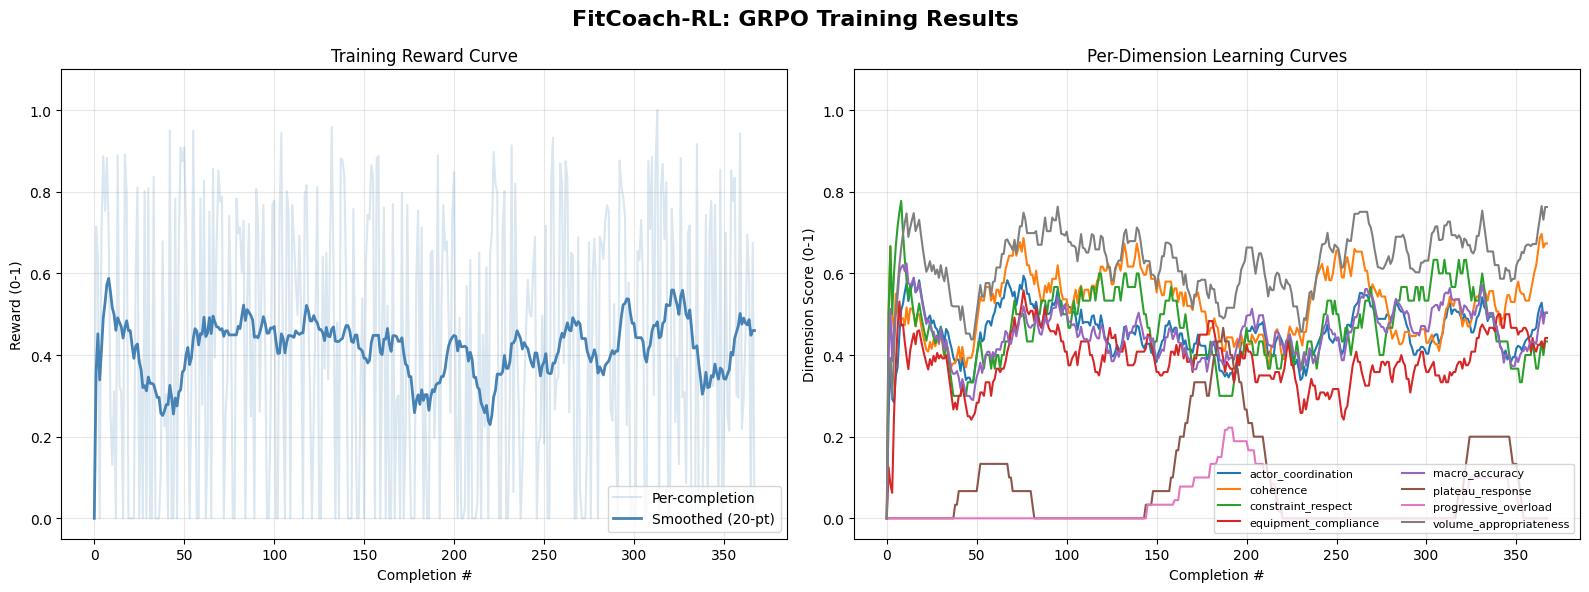


Chart saved to /content/fitcoach_training_results_clean.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FitCoach-RL: GRPO Training Results', fontsize=16, fontweight='bold')

# ── Plot 1: Reward Curve ─────────────────────────────────────────────
ax1 = axes[0]
all_rewards = training_log['step_rewards']

if all_rewards:
    x = list(range(len(all_rewards)))
    window = min(20, len(all_rewards) // 3 + 1)

    smoothed = [
        float(np.mean(all_rewards[max(0, i - window + 1):i + 1]))
        for i in range(len(all_rewards))
    ]

    ax1.plot(x, all_rewards, alpha=0.2, color='steelblue', label='Per-completion')
    ax1.plot(x, smoothed, color='steelblue', linewidth=2, label=f'Smoothed ({window}-pt)')

ax1.set_xlabel('Completion #')
ax1.set_ylabel('Reward (0-1)')
ax1.set_title('Training Reward Curve')
ax1.legend(loc='lower right')
ax1.set_ylim(-0.05, 1.1)
ax1.grid(alpha=0.3)


# ── Plot 2: Per-Dimension Learning Curves ─────────────────────────────
ax2 = axes[1]
breakdowns = training_log['step_breakdowns']

if breakdowns:
    all_dims = sorted({k for bd in breakdowns for k in bd.keys()})
    dim_window = min(30, len(breakdowns) // 3 + 1)

    for dim in all_dims:
        dim_vals = [bd.get(dim, 0) for bd in breakdowns]

        dim_smooth = [
            float(np.mean(dim_vals[max(0, i - dim_window + 1):i + 1]))
            for i in range(len(dim_vals))
        ]

        ax2.plot(dim_smooth, label=dim, linewidth=1.5)

    ax2.set_xlabel('Completion #')
    ax2.set_ylabel('Dimension Score (0-1)')
    ax2.set_title('Per-Dimension Learning Curves')
    ax2.legend(fontsize=8, ncol=2, loc='lower right')
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(alpha=0.3)

else:
    ax2.text(0.5, 0.5, 'No breakdown data', ha='center', va='center')


# ── Final Layout ─────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('/content/fitcoach_training_results_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nChart saved to /content/fitcoach_training_results_clean.png')

## Step 11 — Save / push the LoRA adapter (optional)

In [ ]:
model.save_pretrained('/content/fitcoach_grpo_lora')
tokenizer.save_pretrained('/content/fitcoach_grpo_lora')
print('LoRA adapter saved to /content/fitcoach_grpo_lora')

PUSH_TO_HUB = False
HF_TOKEN    = 'hidden'
HF_REPO     = 'coffeine16/fitcoach-grpo-qwen2.5-1.5b'

if PUSH_TO_HUB and HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    model.push_to_hub(HF_REPO)
    tokenizer.push_to_hub(HF_REPO)
    print('Pushed to', HF_REPO)
else:
    print('Skipping HF push (set PUSH_TO_HUB=True and HF_TOKEN to enable).')

Unsloth: Restored added_tokens_decoder metadata in /content/fitcoach_grpo_lora/tokenizer_config.json.


LoRA adapter saved to /content/fitcoach_grpo_lora
Skipping HF push (set PUSH_TO_HUB=True and HF_TOKEN to enable).
